In [1]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig
from PIL import Image
import numpy as np


CHECKPOINT_PATH = "Models/vit_crop/checkpoint-32110"
config = ViTConfig.from_pretrained(CHECKPOINT_PATH, output_attentions=True)

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH, config=config)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}")

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded from Models/vit_crop/checkpoint-32110
Using device: mps


In [2]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id
print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [3]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
        
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()


In [4]:
def generate_grad_rollout(model, processor, pil_image, target_class_id):

    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    model.eval() 
    outputs = model(**inputs)
    logits = outputs.logits
    attentions = outputs.attentions 
    
    target_logit = logits[0, target_class_id]
    
    model.zero_grad()
    grads = torch.autograd.grad(target_logit, attentions, retain_graph=True, allow_unused=True)
    
    with torch.no_grad():
        num_tokens = attentions[0].shape[-1]
        rollout = torch.eye(num_tokens, device=device) 
        
        for i in range(len(attentions)):
            A_l = attentions[i] 
            G_l = grads[i]      
            
            if G_l is None:
                continue
            
            A_l = A_l.squeeze(0) 
            G_l = G_l.squeeze(0) 
            
            alpha = torch.mean(G_l, dim=(-1, -2))    
            alpha = torch.nn.functional.relu(alpha) 
            
            alpha_sum = torch.sum(alpha)
            if alpha_sum > 0:
                alpha = alpha / alpha_sum
            else:
                alpha = torch.ones_like(alpha) / alpha.shape[0]

            A_l_avg = torch.einsum('h,hsd->sd', alpha, A_l) 
            
            I = torch.eye(num_tokens, device=device)
            A_l_avg = A_l_avg + I
            
            A_l_avg = A_l_avg / A_l_avg.sum(dim=-1, keepdim=True)
            
            rollout = torch.matmul(A_l_avg, rollout)
            
    cls_attention_map = rollout[0, 1:] 
    num_patches_side = int(cls_attention_map.shape[0]**0.5)
    heatmap = cls_attention_map.reshape(num_patches_side, num_patches_side).cpu().numpy()
    
    return heatmap

In [5]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [6]:
graph = Neo4jGraph(url="neo4j://127.0.0.1:7687", username=os.getenv("NEO4J_USER"), password=os.getenv("NEO4J_PASSWORD"), enhanced_schema=True)

In [7]:
llm = ChatGoogleGenerativeAI(
    model="models/gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [8]:
ANSWER_GEN_TEMPLATE = """
### Role
You are an expert AI agricultural assistant. Your job is to provide a **precise, scientifically reliable, and user-focused** answer to the user's question about their plant.

### Information Provided
You are given the following:

1. **[Original User Question]** — This is what you must answer.
2. **[Diagnosis]** — The disease or condition detected from the image (e.g., a specific disease or "Healthy").
3. **[Retrieved Knowledge]** — A small, relevant knowledge subgraph about the diagnosis (crop → disease → symptoms → treatments).


### How to Use This Information
- Use **[Diagnosis]** to determine *what is happening* with the plant.
- Use **[Retrieved Knowledge]** to provide:
  - brief scientific justification,
  - symptom reasoning,
  - actionable recommendations,
  - or reassurance if the plant is healthy.
- You are NOT allowed to question, re-verify, or contradict the diagnosis.
- In case of contradictions between the user's question and the diagnosis, always trust the diagnosis and correct the user.

### Critical Rules (Follow Strictly)
1. **Directly answer the user's question** — this is your top priority.
2. Your answer must be:
   - **specific**,  
   - **scientifically grounded**,  
   - **clear and concise**,  
   - **actionable when needed**.
2. For "what/why/how" questions:
   - Provide a short explanation using the knowledge graph.
3. **Do NOT**:
   - Mention the knowledge graph itself.
   - Say "I cannot confirm", "I cannot verify", or anything uncertain.
   - Add unrelated information.
   - Give unsafe chemical advice.


### Output Style
- 2-4 sentences maximum.
- No lists unless absolutely necessary.
- Must sound like an agricultural expert answering a farmer.

Crop: {crop}
Diagnosis: {disease}

<context>
{context}
</context>

Question: {question}
Answer:
"""


In [9]:
from langchain_core.prompts import PromptTemplate
ANSWER_GEN_PROMPT = PromptTemplate.from_template(ANSWER_GEN_TEMPLATE)

In [10]:
answer_chain = ANSWER_GEN_PROMPT | llm

In [69]:
CYPHER_SUBGRAPH = """
MATCH (d:Entity {name: $disease})
    OPTIONAL MATCH (d)-[rA:AFFECTS]->(c:Entity)
    OPTIONAL MATCH (d)-[rPRESENTS:PRESENTS]->(s:Entity)
    OPTIONAL MATCH (d)-[rPATHOGEN:CAUSED_BY]->(p:Entity)
    OPTIONAL MATCH (d)-[rTREAT:TREATED_BY]->(t:Entity)

    WITH 
        COLLECT(DISTINCT d) +
        COLLECT(DISTINCT c) +
        COLLECT(DISTINCT s) +
        COLLECT(DISTINCT p) +
        COLLECT(DISTINCT t) AS nodes,
        COLLECT(rA) + 
        COLLECT(rPRESENTS) +
        COLLECT(rPATHOGEN) + 
        COLLECT(rTREAT) AS rels,
        d

    RETURN nodes, rels
"""


In [70]:
raw = graph.query(CYPHER_SUBGRAPH, params={"disease": "Black Rot"})
raw[0]['rels']

[({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grapes'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grapes'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grapes'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grapes'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grapes'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Apple'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name': 'Grape'}),
 ({'name': 'Black Rot'}, 'AFFECTS', {'name'

In [61]:
def cleanup_relationships(raw):
    unique_simplified_tuples = set()
    for d1, r, d2 in raw:
        simplified_tuple = (d1['name'], r, d2['name']) 
        unique_simplified_tuples.add(simplified_tuple)

    deduplicated_list = []
    for name1, r, name2 in unique_simplified_tuples:
        original_format_tuple = ({'name': name1}, r, {'name': name2})
        deduplicated_list.append(original_format_tuple)

    return deduplicated_list

In [68]:
cleanup_relationships(raw[0]['rels'])

[({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Branch infections'}),
 ({'name': 'Black Rot'}, 'TREATED_BY', {'name': 'Thiophanate-methyl'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Rough bark'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Circular lesions'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Fruit infections'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Frog-eye-like spots'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Target-like appearance'}),
 ({'name': 'Black Rot'}, 'TREATED_BY', {'name': 'Bordeaux mixture'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Gray-white centers'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Black-brown spots'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Dark lesions'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Shriveled fruit'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Elliptical lesions'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {'name': 'Shriveled fruits'}),
 ({'name': 'Black Rot'}, 'PRESENTS', {

In [28]:
CYPHER_SUBGRAPH_H = """
        MATCH (d:Entity)-[r:AFFECTS]->(c:Entity {name: $crop})
        RETURN DISTINCT 
            d.name AS disease,
            type(r) AS relationship,
            c.name AS crop
        """
CYPHER_SUBGRAPH_D =  """
    MATCH (d:Entity {name: $disease})
    MATCH (c:Entity {name: $crop})
    MATCH (d)-[rA:AFFECTS]->(c)

    OPTIONAL MATCH (d)-[rPRESENTS:PRESENTS]->(s:Entity)
    OPTIONAL MATCH (d)-[rPATHOGEN:CAUSED_BY]->(p:Entity)
    OPTIONAL MATCH (d)-[rTREAT:TREATED_BY]->(t:Entity)

    WITH 
         COLLECT(DISTINCT d) +
         COLLECT(DISTINCT c) +
         COLLECT(DISTINCT s) +
         COLLECT(DISTINCT p) +
         COLLECT(DISTINCT t) AS nodes,
         COLLECT(rA) + 
         COLLECT(rPRESENTS) +
         COLLECT(rPATHOGEN) + 
         COLLECT(rTREAT) AS rels

    RETURN nodes, rels
    """


Predicted class: 'Tomato,Healthy' (ID: 44)


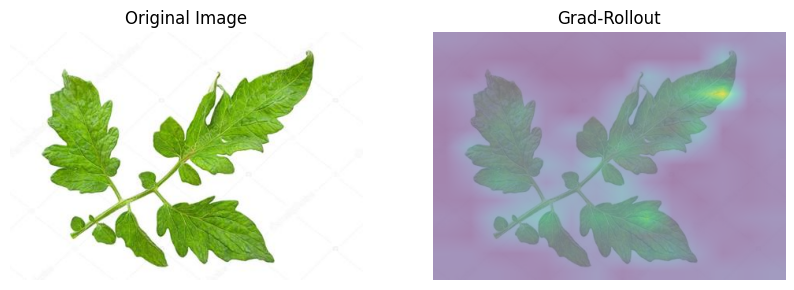

No.


In [ ]:
YOUR_IMAGE_PATH_HERE = "dataset/images/Tomato,Healthy/plant_22163.jpg"
YOUR_QUERY_HERE = "Is this crop diseased?"

try:
    image_pil = Image.open(YOUR_IMAGE_PATH_HERE).convert("RGB")
    image_np = np.array(image_pil)

    probs = predict_fn([image_np])
    predicted_class_id = np.argmax(probs[0])
    predicted_class_name = id_to_class[predicted_class_id]
    print(f"Predicted class: '{predicted_class_name}' (ID: {predicted_class_id})")

    heatmap = generate_grad_rollout(
        inference_model, 
        inference_processor, 
        image_pil, 
        predicted_class_id
    )
    
    import matplotlib.pyplot as plt
    import cv2
    
    img_size = inference_processor.size['height']
    heatmap_resized = cv2.resize(heatmap, (image_pil.width, image_pil.height))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image_pil)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-Rollout")
    plt.imshow(image_pil, alpha=0.5)
    plt.imshow(heatmap_resized, cmap='viridis', alpha=0.5)
    plt.axis('off')
    plt.show()

    crop, dis = predicted_class_name.split(',')
    
    subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
    answer = answer_chain.invoke({
        "question": YOUR_QUERY_HERE,
        "context": str(subgraph)
    })
    gen = answer.content
    print(gen)
    
except FileNotFoundError:
    print(f"Error: Image file not found at '{YOUR_IMAGE_PATH_HERE}'")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure your image file is a valid format (JPG, PNG, etc.)")

In [42]:
def load_crops_and_diseases(images_root='dataset/images'):
    crops_set = set()
    diseases_set = set()

    if not os.path.isdir(images_root):
        return [], []

    for entry in os.listdir(images_root):
        path = os.path.join(images_root, entry)
        if not os.path.isdir(path):
            continue

        if ',' in entry:
            crop, disease = [p.strip() for p in entry.split(',', 1)]
        else:
            crop = entry.strip()
            disease = ''

        if crop:
            crops_set.add(crop)
        if disease:
            diseases_set.add(disease)

    return sorted(crops_set), sorted(diseases_set)


CROPS, DISEASES = load_crops_and_diseases()


In [45]:
print(f'Crops: {len(CROPS)}')
print(f'Diseases: {len(DISEASES)}')

Crops: 16
Diseases: 33


In [ ]:
from collections import Counter
import os

def load_crops_and_diseases(images_root='dataset/images'):
    crops_set = set()
    diseases_list = []   

    if not os.path.isdir(images_root):
        return [], [], {}

    for entry in os.listdir(images_root):
        path = os.path.join(images_root, entry)
        if not os.path.isdir(path):
            continue

        if ',' in entry:
            crop, disease = [p.strip() for p in entry.split(',', 1)]
        else:
            crop = entry.strip()
            disease = ''

        if crop:
            crops_set.add(crop)
        if disease:
            diseases_list.append(disease)

    disease_counts = Counter(diseases_list)
    
    repeated_diseases = {d: c for d, c in disease_counts.items() if c >= 2}

    return (
        sorted(crops_set),
        sorted(set(diseases_list)),
        repeated_diseases  
    )


# Usage
CROPS, DISEASES, REPEATED_DISEASES = load_crops_and_diseases()
REPEATED_DISEASES

{'Leaf Rust': 3,
 'Bacterial Spot': 3,
 'Brown Spot': 2,
 'Leaf Blight': 2,
 'Septoria Leaf Spot': 2,
 'Late Blight': 2,
 'Powdery Mildew': 4,
 'Black Rot': 2,
 'Healthy': 14,
 'Mosaic Virus': 2,
 'Early Blight': 2}

In [32]:
from rapidfuzz import process, fuzz

def extract_from_text(query):
    if not query:
        return None, None

    q = query.lower()
    crop = None
    disease = None

    for c in CROPS:
        if c.lower() in q:
            crop = c
            break

    for d in DISEASES:
        if d.lower() in q:
            disease = d
            break

    if not crop:
        match = process.extractOne(query, CROPS, scorer=fuzz.partial_ratio)
        if match and match[1] >= 90:
            crop = match[0]

    if not disease:
        match = process.extractOne(query, DISEASES, scorer=fuzz.partial_ratio)
        if match and match[1] >= 90:
            disease = match[0]

    if not disease: 
        disease = "Healthy"
        
    return crop, disease

In [37]:
YOUR_IMAGE_PATH_HERE = None
YOUR_QUERY_HERE = "what all diseases affect rice?"

def run_pipeline_hybrid(query, image=None):
    if image:
        img = Image.open(image).convert("RGB")
        img_np = np.array(img)

        probs = predict_fn([img_np])
        class_id = np.argmax(probs[0])
        predicted_class_name = id_to_class[class_id]

        print(f"[VISION] Predicted: {predicted_class_name}")

        heatmap = generate_grad_rollout(inference_model, inference_processor, img, class_id)
        heatmap_resized = cv2.resize(heatmap, (img.width, img.height))

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("Grad-Rollout")
        plt.imshow(img, alpha=0.5)
        plt.imshow(heatmap_resized, cmap="viridis", alpha=0.5)
        plt.axis("off")
        plt.show()

        crop, dis = predicted_class_name.split(',')
        print(f"[DETECTED] Crop={crop}, Disease={dis}")
        if dis.lower() == "healthy":
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_H
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })
        else:
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_D
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
            subgraph = cleanup_relationships(subgraph)

        answer = answer_chain.invoke({
            "question": query,
            "context": str(subgraph),
            "crop": crop,
            "disease": dis
        })
        return answer.content, subgraph

    else:
        
        crop, dis = extract_from_text(
            YOUR_QUERY_HERE,
        )
        print(f"[DETECTED] Crop={crop}, Disease={dis}")
        if dis.lower() == "healthy":
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_H
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })
        else:
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_D
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
            subgraph = cleanup_relationships(subgraph)

        answer = answer_chain.invoke({
            "question": query,
            "context": str(subgraph),
            "crop": crop,
            "disease": dis
        })
        return answer.content, subgraph

[VISION] Predicted: Potato,Late Blight


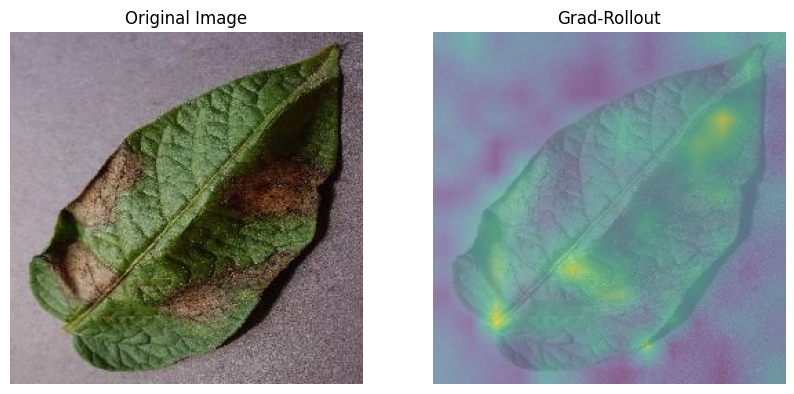

[DETECTED] Crop=Potato, Disease=Late Blight


('Your potato plant is suffering from Late Blight, a destructive disease caused by the oomycete *Phytophthora infestans*. This condition is characterized by the rapid development of large, irregularly shaped, water-soaked lesions on the leaves, which quickly turn dark brown or black and may exhibit white fungal growth, especially on the underside.',
 [({'name': 'Late Blight'}, 'PRESENTS', {'name': 'Oil-soaked spots'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'Irregularly shaped'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'White mold'}),
  ({'name': 'Late Blight'},
   'PRESENTS',
   {'name': 'Brown or purple-brown sunken lesions'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'Dark lesions'}),
  ({'name': 'Late Blight'}, 'AFFECTS', {'name': 'Potato'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'White fungal growth'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'Water-soaked spots'}),
  ({'name': 'Late Blight'}, 'PRESENTS', {'name': 'Dark brown sunken 

In [38]:
import matplotlib.pyplot as plt
import cv2

run_pipeline_hybrid("What is happening to my plant?", "dataset/images/Potato,Late Blight/plant_65637.jpg")

In [25]:
def run_pipeline(image, query):

    try:
        image_pil = Image.open(image).convert("RGB")
        image_np = np.array(image_pil)

        probs = predict_fn([image_np])
        predicted_class_id = np.argmax(probs[0])
        predicted_class_name = id_to_class[predicted_class_id]
    
        crop, dis = predicted_class_name.split(',')
        if dis.lower() == "healthy":
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_H
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })
        else:
            CYPHER_SUBGRAPH = CYPHER_SUBGRAPH_D
            subgraph = graph.query(CYPHER_SUBGRAPH, params={"disease": dis, "crop" : crop })[0]['rels']
            subgraph = cleanup_relationships(subgraph)
        answer = answer_chain.invoke({
            "question": query,
            "context": str(subgraph),
            "crop": crop,
            "disease": dis
        })
        return answer.content, subgraph
        
    except FileNotFoundError:
        print(f"Error: Image file not found at '{image}'")
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure your image file is a valid format (JPG, PNG, etc.)")


In [26]:
ans, sub = run_pipeline("dataset/images/Bell Pepper,Healthy/plant_128655.jpg", "What all diseases can my plant have?")
ans

'Your bell pepper plant is currently healthy. While your plant shows no signs of disease, bell peppers can be susceptible to conditions such as Bacterial Spot.'

In [ ]:
sub

In [133]:
from langchain_core.prompts import PromptTemplate

JUDGE_PROMPT = """
You are an evaluation assistant for an agricultural Question-Answering system.

Your task is to evaluate the **overall correctness** of the system answer using a
hybrid method:

1. **Faithfulness to the Knowledge Graph (KG)**  
   - The system answer should not contradict the reference answer.
   - It should not introduce major factual errors.
   - Minor additional details are allowed **if they are scientifically accurate**.

2. **General Scientific Correctness**  
   - Even if the system adds information not in the reference, it is acceptable
     **as long as it is biologically plausible, commonly known, and helpful**.
   - Small expansions (e.g., naming pathogens, describing typical symptoms)
     should NOT be penalized if correct.

3. **Completeness & Relevance**  
   - Does the system answer provide the essential meaning of the reference?
   - Is it directly answering the user’s question?
   - Is it missing any critical facts from the reference answer?

4. **Hallucination Control**  
   - Penalize only:
     - incorrect biological claims,
     - fabricated diseases/treatments,
     - statements that contradict the reference,
     - unsafe recommendations.
   - Do NOT penalize harmless or accurate elaboration that aligns with plant pathology.

---

### Scoring Guidelines (Hybrid)

**Score 1.0 — Excellent**
- Meaning fully aligns with the reference.
- No contradictions.
- Any extra details are scientifically correct and helpful.
- No omissions of essential facts.

**Score 0.75 — Good**
- Mostly correct.
- May miss a minor detail OR include small but correct elaborations.
- No contradictions or harmful hallucinations.

**Score 0.5 — Mixed**
- Partially correct but missing important facts **OR**
  contains minor biological inaccuracies.
- Still generally aligned with the reference.

**Score 0.25 — Poor**
- Major omissions OR multiple incorrect facts.
- Contradicts important parts of the reference.

**Score 0.0 — Incorrect/Harmful**
- Contradicts the reference answer.
- Contains biologically incorrect statements or unsafe recommendations.
- Introduces fake diseases or false facts.

---

### Output Format (JSON only)

{{
  "score": float (0 to 1),
  "explanation": "Brief explanation of correctness and issues"
}}

---

QUESTION: {question}
REFERENCE_ANSWER: {reference}
SYSTEM_ANSWER: {system_answer}
"""

JUDGE_PROMPT_TEMPLATE = PromptTemplate.from_template(JUDGE_PROMPT)

In [ ]:
gen

In [ ]:
def evaluate_answer(question, generated_answer, subgraph):
    judge_chain = JUDGE_PROMPT_TEMPLATE | llm
    inputs = {
        "question": question,
        "system_answer": generated_answer,
        "reference": subgraph,
    }
    
    evaluation = judge_chain.invoke(inputs)
    return evaluation

In [ ]:
evaluate_answer(
    question="What are the effective control measures that can be implemented to manage Tomato Leaf Mold?",
    subgraph=subgraph,
    generated_answer=gen
).content

In [135]:
import re

def extract_json(text):
    pattern = r"\{[\s\S]*?\}"
    match = re.search(pattern, text)
    if not match:
        raise ValueError("No JSON object found in the text.")

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        raise ValueError("Found JSON-like content but failed to parse.")

In [ ]:
import json
import csv
from tqdm import tqdm

def run_full_test(
    test_json_path,
    output_csv_path,
):

    with open(test_json_path, "r") as f:
        dataset = json.load(f)

    with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "question_id",
                "image",
                "question",
                "system_answer",
                "judge_score",
                "explanations",
            ]
        )
        writer.writeheader()

    for item in tqdm(dataset, desc="Running tests"):
        q_id = item.get("question_id")
        image = item.get("image")

        if image.startswith("/"):
            image = image[1:]

        question = item.get("question")

        try:
            system_answer, subgraph = run_pipeline(image, question)
        except Exception as e:
            system_answer = f"PIPELINE ERROR: {str(e)}"
            subgraph = ""

        try:
            eval1_text = evaluate_answer(question, system_answer, subgraph).content
            judge_score = extract_json(eval1_text).get('score')
            explainations = extract_json(eval1_text).get('explanation')

            print(f"Evaluated QID {q_id}: score = {judge_score}")

        except Exception as e:
            print(e)
            break

        # Append single row
        with open(output_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=[
                "question_id",
                "image",
                "question",
                "system_answer",
                "judge_score",
                "explanations",
            ])
            writer.writerow({
                "question_id": q_id,
                "image": image,
                "question": question,
                "system_answer": system_answer,
                "judge_score": judge_score,
                "explanations": explainations,
            })

    print(f"Saved results to {output_csv_path}")


In [ ]:
run_full_test(
    test_json_path="dataset/test_dataset/disease_diagnosis.json",
    output_csv_path="Results/test_2.csv",
)

In [1]:
import csv

def compute_avg_score(csv_path):
    scores = []

    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                score = float(row["judge_score"])
                scores.append(score)
            except:
                pass  

    if len(scores) == 0:
        raise ValueError("No judge_score values found.")

    avg_score = sum(scores) / len(scores)

    return avg_score

In [3]:
avg = (compute_avg_score("Results/test_1.csv") + compute_avg_score("Results/test_2.csv")) / 2
print("Average Score (0-1):", avg)

Average Score (0-1): 0.9104166666666667
